<a href="https://colab.research.google.com/github/lixiaokun2020/TCRdesign/blob/main/Code/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Pre-training for α-Roformer and β-Roformer.

In [ ]:
#Now your path is: TCRdesign/Code/
! python pretrain_maa_main.py --config ./config/common/pretrain_maa_common_alpha.json

In [ ]:
! python pretrain_maa_main.py --config ./config/common/pretrain_maa_common_beta.json

When you completed the pre-training for α-Roformer and β-Roformer, your models are saved in:

`../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX/` ------- β-Roformer

`../Result_alpha/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX` ------- α-Roformer

where XXXX_XXXXXX is the timestamp of the training.

# Step 2: Training TCRBinder on Antigen-TCR binding data

Due to the use of ESM2 model parameters as the antigen model, there may be network errors when downloading ESM2 model parameters. Please check the network settings or try again later. You can also download files in [huggingface](https://huggingface.co/facebook/esm2_t30_150M_UR50D/tree/main) and put them in ./esm2/esm2_150m and ./cache for tokenizer and model (You are in the '/TCRdesign/Code' now).


Update the `config/common/TCRbinder.josn`, please make sure that:

`"beta_dir": "../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX"`

`"alpha_dir": "../Result_alpha/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX"`

`"antigen_dir": "./esm2/esm2_150m/"`

`"tcr_tokenizer_dir": "../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX"`



In [ ]:
! python finetuning_er_main.py --config ./config/common/TCRBinder.json

/Users/tomasyang/Desktop/TCRdesign/Code/data/bert_finetuning_er_dataset.py:156: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  pair_df = pd.read_csv(self.data_dir)
Shuffling dataset
There are 77528 samples
Using common tokenizer.
Loading pre-trained tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Number of pairs in train: 62024, valid: 7752, and test: 7752.
Some weights of the model checkpoint at ../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/0421_213847 were not used when initializing RoFormerModel: ['cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing RoFormerModel from the checkpoint of a mode

When you have completed this training process, the TCRBinder will be saved in:

`../Result_TP/checkpoints/BERT-Finetunning-TCR-Binding-common-agtcr/XXXX_XXXXXX/` ---TCRBinder


# Step 3: Training TCRdesign on seq2seq generation

Update the `config/common/TCRbinder.josn`, please make sure that:

`"TCRBert_dir": "../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/XXXX_XXXXXX"`

`"AntigenBert_dir": "./esm2/esm2_150m"`

`"tcr_tokenizer_dir": "../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/0421_213847/"`

`"antigen_tokenizer_dir": "../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/0421_213847/"`


In [ ]:
! python finetuning_seq2seq_main.py --config ./config/common/seq2seq_train.json

37988 train and 388 valid and 388 test.
Creating CDR3 tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Creating Antigen tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
The input to the encoder is antigen
The input to the encoder is antigen
The input to the encoder is antigen
Loading TCRBert from ../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/0421_213847/
Loading AntigenBert from ./esm2/esm2_150m
Using AntigenBert as encoder, TCRBert as decoder.
Some weights of the model checkpoint at ./esm2/esm2_150m were not used when initializing EsmModel: ['lm_head.layer_norm.weight', 'esm.contact_head.regression.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.bias', 'lm_head.bias', 'esm.contact_head.regression.bias', 'lm_head.dense.weight', 'lm_head.decoder.weight']
- This IS expected if you are initializing EsmModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassif

When you have completed this training process, the `TCRdesign` will be saved in:

`../Result_TCR_seq2seq/checkpoints/AGTCR-Finetuning-Seq2seq-Common/XXXX_XXXXXX/` ---TCRdesign

# Step 4 Generate artificial TCRs

Update the `seq2seq_generate.json`, please make sure that:

`"resume": "/data/coding/TCRdesign/Result_TCR_seq2seq/checkpoints/AGTCR-Finetuning-Seq2seq-Common/XXXX_XXXXXX"`  ---TCRdesign

`"origin_seq":` ---"Your TCR beta chain sequence"

`"origin_alpha":` ---"Your TCR alpha chain sequence"

`"origin_hla":`   ---"Your antigen"

`"cdr3_begin":` ---"Begin of CDR3"

`"cdr3_end":` ---"End of CDR3"

In [ ]:
! python generate_tcr.py --config ./config/common/seq2seq_generate.json

/Users/tomasyang/Desktop/TCRdesign/Code/data/bert_finetuning_er_seq2seq_dataset.py:205: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.data_dir)
62022 train and 7753 valid and 7753 test.
Creating CDR3 tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Creating Antigen tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
The input to the encoder is Antigen
The input to the encoder is Antigen
The input to the encoder is Antigen
Loading pre-trained model from ../Result_TCR_seq2seq/checkpoints/AGTCR-Finetuning-Seq2seq-Common/0713_084535
The input is antigen, generate tcr sequences.
  0%|                                                     | 0/1 [00:00<?, ?it/s]/Users/tomasyang/anaconda3/envs/DrugBAN/lib/python3.8/site-packages/transformers/generation_beam_search.py:198: UserWarning: Passing `max_length` to BeamSearchScorer is deprecated and has no effect. `max_length` should be 

The artificial TCR will be saved in the:

`../Result_TCR_gen/datasplit/TP-Seq2seq-Evaluate-Common/XXXX_XXXXXX/result.csv`.

# Step 5 Evaluate artificial TCRs

Update the `eval_generation.json`, please make sure that:

`"discriminator_resume": "../Result_TP/checkpoints/BERT-Finetunning-TCR-Binding-common-agtcr/XXXX_XXXXXX/model_best.pth"`

`"data_dir": "../Result_TCR_gen/datasplit/TP-Seq2seq-Evaluate-Common/XXXX_XXXXXX/result.csv"`

In [ ]:
! python eval_generate_seq.py --config ./config/common/bert_eval_generation.json

There are 100 samples
Using common tokenizer.
Loading pre-trained tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Using common tokenizer.
Loading pre-trained tokenizer...
Some weights of the model checkpoint at ../Result_beta/checkpoints/BERT-Pretrain-common-MAA-NGPUs/0421_213847 were not used when initializing RoFormerModel: ['cls.predictions.decoder.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing RoFormerModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RoFormerModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertFor

The evaluation result will be saved in the
../Result_TCR_eval/datasplit/Eval-genetation/XXXX_XXXXXX/test_result.csv
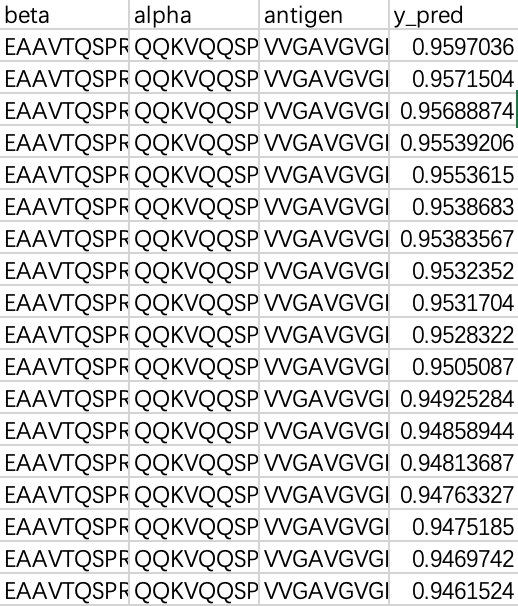